# Notebook 2 — Feature Engineering

Builds the supervised-learning feature matrix from the cleaned daily series.

**Features created:**
- Lag features (1, 7, 14, 30 days)
- Rolling statistics (mean & std for 7, 14, 28-day windows)
- Calendar features (day of week, month, week, is_weekend)
- Exogenous features (oil price, oil lags, is_national_holiday, store_open)

## 1. Imports

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 4)})

DATA_DIR = '../data/'
print('Libraries loaded ✓')


Libraries loaded ✓


## 2. Load Cleaned Data

In [13]:
daily = pd.read_csv(DATA_DIR + 'timeseries_clean.csv', parse_dates=['date'])
daily = daily.sort_values('date').reset_index(drop=True)
print(f'Loaded: {len(daily)} rows')
daily.head()


Loaded: 454 rows


,date,unit_sales,is_national_holiday,store_open,dcoilwtico,day_of_week,day_name,month,month_name,week,year,is_weekend,split
0,2013-01-02,582.0,0,1,93.14,2,Wednesday,1,Jan,1,2013,0,train
1,2013-01-03,310.0,0,1,92.97,3,Thursday,1,Jan,1,2013,0,train
2,2013-01-04,338.0,0,1,93.12,4,Friday,1,Jan,1,2013,0,train
3,2013-01-05,654.0,1,1,93.12,5,Saturday,1,Jan,1,2013,1,train
4,2013-01-06,979.0,0,1,93.12,6,Sunday,1,Jan,1,2013,1,train


## 3. Create Lag Features

Lag features let the model see recent history as input. We use 1, 7, 14, and 30-day lags.

In [14]:
for lag in [1, 7, 14, 30]:
    daily[f'lag_{lag}'] = daily['unit_sales'].shift(lag)

print('Lag features created: lag_1, lag_7, lag_14, lag_30')
daily[['date', 'unit_sales', 'lag_1', 'lag_7', 'lag_14', 'lag_30']].head(35).tail(10)


Lag features created: lag_1, lag_7, lag_14, lag_30


,date,unit_sales,lag_1,lag_7,lag_14,lag_30
25,2013-01-27,616.0,697.0,1090.0,679.0,NaN
26,2013-01-28,318.0,616.0,760.0,683.0,NaN
27,2013-01-29,393.0,318.0,461.0,547.0,NaN
28,2013-01-30,487.0,393.0,413.0,265.0,NaN
29,2013-01-31,282.0,487.0,326.0,4.0,NaN
30,2013-02-01,401.0,282.0,389.0,60.0,582.0
31,2013-02-02,775.0,401.0,697.0,667.0,310.0
32,2013-02-03,855.0,775.0,616.0,1090.0,338.0
33,2013-02-04,411.0,855.0,318.0,760.0,654.0
34,2013-02-05,272.0,411.0,393.0,461.0,979.0


## 4. Rolling Statistics

Rolling mean and standard deviation capture recent trends and volatility.

In [15]:
for window in [7, 14, 28]:
    daily[f'roll_mean_{window}'] = daily['unit_sales'].shift(1).rolling(window).mean()
    daily[f'roll_std_{window}']  = daily['unit_sales'].shift(1).rolling(window).std()

roll_cols = [c for c in daily.columns if 'roll_' in c]
print(f'Rolling features created: {roll_cols}')


Rolling features created: ['roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']


## 5. Calendar Features

In [16]:
# Already have: day_of_week, month, week, year, is_weekend, is_national_holiday, store_open
# Add month for models that don't have it yet
if 'day_of_week' not in daily.columns:
    daily['day_of_week'] = daily['date'].dt.dayofweek
if 'month' not in daily.columns:
    daily['month'] = daily['date'].dt.month
if 'week' not in daily.columns:
    daily['week'] = daily['date'].dt.isocalendar().week.astype(int)
if 'year' not in daily.columns:
    daily['year'] = daily['date'].dt.year
if 'is_weekend' not in daily.columns:
    daily['is_weekend'] = (daily['day_of_week'] >= 5).astype(int)

calendar_cols = ['day_of_week', 'month', 'week', 'year', 'is_weekend']
print(f'Calendar features: {calendar_cols}')


Calendar features: ['day_of_week', 'month', 'week', 'year', 'is_weekend']


## 6. Oil Price Lags

In [17]:
daily['oil_lag_1'] = daily['dcoilwtico'].shift(1)
daily['oil_lag_7'] = daily['dcoilwtico'].shift(7)

print('Oil lag features created: oil_lag_1, oil_lag_7')


Oil lag features created: oil_lag_1, oil_lag_7


## 7. Feature Summary

In [18]:
feature_cols = (
    ['lag_1', 'lag_7', 'lag_14', 'lag_30']
    + [f'roll_mean_{w}' for w in [7, 14, 28]]
    + [f'roll_std_{w}'  for w in [7, 14, 28]]
    + ['day_of_week', 'month', 'week', 'is_weekend']
    + ['dcoilwtico', 'oil_lag_1', 'oil_lag_7', 'is_national_holiday', 'store_open']
)

print(f'Total features: {len(feature_cols)}')
print()
groups = {
    'Lag features (4)'       : [f for f in feature_cols if f.startswith('lag_')],
    'Rolling stats (6)'      : [f for f in feature_cols if f.startswith('roll_')],
    'Calendar (4)'           : ['day_of_week', 'month', 'week', 'is_weekend'],
    'Exogenous (5)'          : ['dcoilwtico', 'oil_lag_1', 'oil_lag_7', 'is_national_holiday', 'store_open'],
}
for grp, cols in groups.items():
    print(f'  {grp}: {cols}')


Total features: 19

  Lag features (4): ['lag_1', 'lag_7', 'lag_14', 'lag_30']
  Rolling stats (6): ['roll_mean_7', 'roll_mean_14', 'roll_mean_28', 'roll_std_7', 'roll_std_14', 'roll_std_28']
  Calendar (4): ['day_of_week', 'month', 'week', 'is_weekend']
  Exogenous (5): ['dcoilwtico', 'oil_lag_1', 'oil_lag_7', 'is_national_holiday', 'store_open']


## 8. Drop Rows with NaN (from lags/rolling)

The first 30 rows will have NaN in lag/rolling features and must be removed before ML training.

In [19]:
df_features = daily[['date', 'unit_sales', 'split'] + feature_cols].copy()
df_features = df_features.dropna().reset_index(drop=True)

print(f'Rows before dropping NaN : {len(daily)}')
print(f'Rows after  dropping NaN : {len(df_features)}')
print(f'Rows dropped (lag warmup): {len(daily) - len(df_features)}')


Rows before dropping NaN : 454
Rows after  dropping NaN : 424
Rows dropped (lag warmup): 30


## 9. Feature Correlation Heatmap

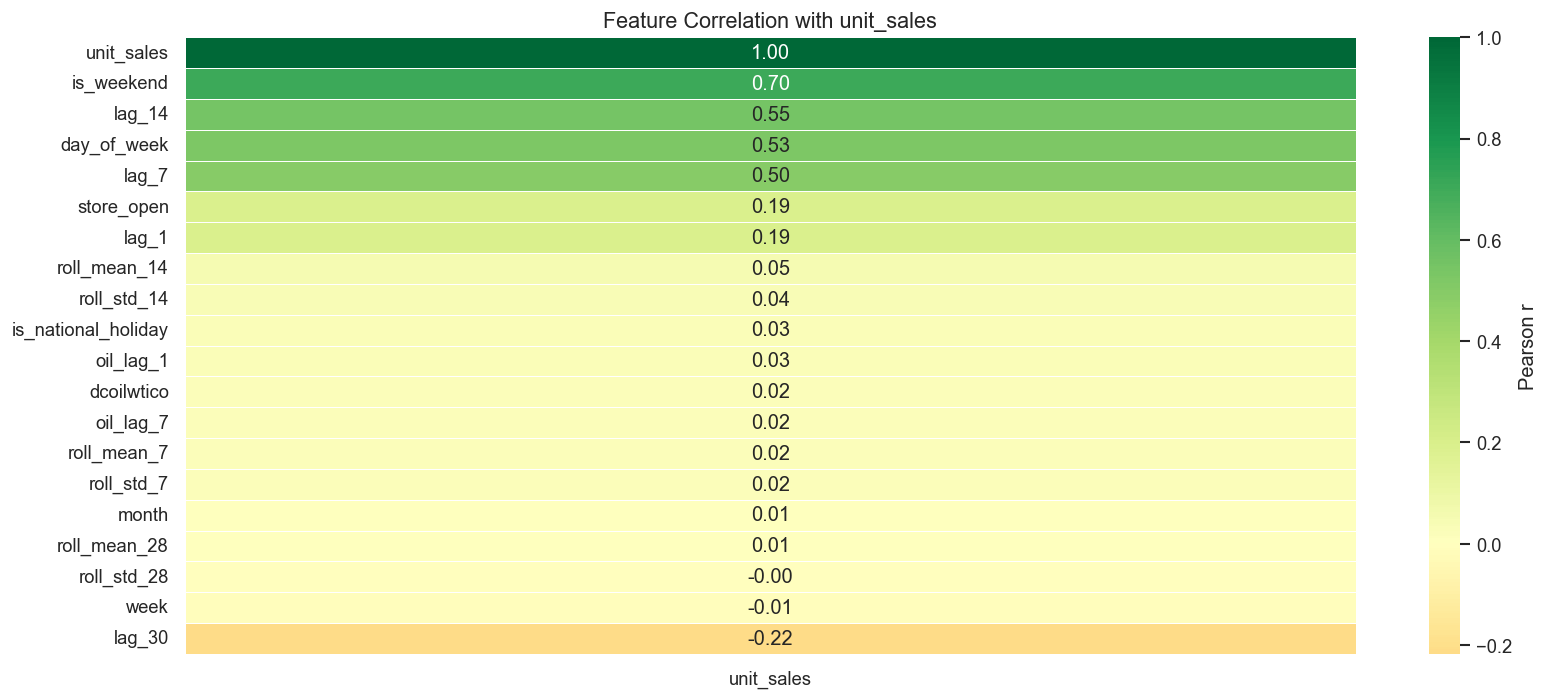

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
corr = df_features[feature_cols + ['unit_sales']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr[['unit_sales']].sort_values('unit_sales', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
ax.set_title('Feature Correlation with unit_sales', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Train / Test Split

In [21]:
train = df_features[df_features.split == 'train'].copy()
test  = df_features[df_features.split == 'test'].copy()

X_train = train[feature_cols]
y_train = train['unit_sales']
X_test  = test[feature_cols]
y_test  = test['unit_sales']

print(f'Train: {len(X_train)} rows')
print(f'Test : {len(X_test)}  rows')
print(f'\nFeature matrix shape: {X_train.shape}')


Train: 334 rows
Test : 90  rows

Feature matrix shape: (334, 19)


## 11. Save Feature-Engineered Dataset

In [22]:
import json

df_features.to_csv(DATA_DIR + 'timeseries_features.csv', index=False)

with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)

print('✅ Saved:')
print('   ../data/timeseries_features.csv')
print('   ../models/feature_columns.json')


✅ Saved:
   ../data/timeseries_features.csv
   ../models/feature_columns.json
